# RIRD — Exploratory Data Analysis
**Thai Food Recommendation Engine (Group: Flower)**

Dataset: `datasets/rir_data-main/` — the Reviewed-Item Retrieval Dataset (RIRD, ECIR 2023).

This notebook explores the two data files and answers one framing question:
**should the engine's input query be Thai or English for this dataset?**

- `PMD.csv` — query × restaurant relevance annotations (ground truth)
- `reviews/50_restaurants_all_rates.csv` — Yelp reviews for the 50 restaurants

> Run with the **cpdsai** venv kernel.


In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# resolve repo root whether run from eda/ or repo root
HERE = Path.cwd()
ROOT = HERE if (HERE / "datasets").exists() else HERE.parent
DATA = ROOT / "datasets" / "rir_data-main"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
print("data dir:", DATA)

data dir: /Users/samichirungta/Desktop/computer_programming/reccomender_project/Food_Recommendation_Engine/datasets/rir_data-main


In [2]:
# quick Unicode-based script detector (Thai vs Latin)
THAI = re.compile(r"[\u0e00-\u0e7f]")
LATIN = re.compile(r"[A-Za-z]")

def script_of(text):
    if not isinstance(text, str) or not text.strip():
        return "empty"
    t, l = bool(THAI.search(text)), bool(LATIN.search(text))
    if t and l: return "mixed"
    if t: return "thai"
    if l: return "latin"
    return "other"

## 1. Reviews — `50_restaurants_all_rates.csv`

In [3]:
rev = pd.read_csv(DATA / "reviews" / "50_restaurants_all_rates.csv")
rev = rev.drop(columns=[c for c in rev.columns if c.startswith("Unnamed")])
print("shape:", rev.shape)
rev.head(3)

shape: (29168, 7)


,business_id,user_id,review_stars,review_text,name,categories,date
0,DE89UdHFMCN6DtYWZuer5A,Cqe3kUtSdFXc7YTA4jYAtg,3.0,Bit of a wait at the door. No problem. Spicy k...,Hokkaido Ramen Santouka,"Ramen, Noodles",2019-01-20
1,DE89UdHFMCN6DtYWZuer5A,NtfB0Aq8puw0Hpetewc0FQ,4.0,"Not sure why, but the shoyu broth and noodle h...",Hokkaido Ramen Santouka,"Ramen, Noodles",2018-10-27
2,DE89UdHFMCN6DtYWZuer5A,szUqQBw8Xl5RExjRqTQsoQ,5.0,It should come to no surprise that I am a huge...,Hokkaido Ramen Santouka,"Ramen, Noodles",2018-04-07


In [4]:
print(rev.dtypes, "\n")
print("missing:\n", rev.isna().sum(), "\n")
print("restaurants:", rev["business_id"].nunique(),
      "| users:", rev["user_id"].nunique(),
      "| dup rows:", rev.duplicated().sum())

business_id      object
user_id          object
review_stars    float64
review_text      object
name             object
categories       object
date             object
dtype: object 

missing:
 business_id     0
user_id         0
review_stars    0
review_text     0
name            0
categories      0
date            0
dtype: int64 

restaurants: 50 | users: 17334 | dup rows: 0


### 1a. Rating distribution
Ratings skew positive — the paper kept only restaurants with avg rating ≥ 3.

review_stars
1.0     1515
2.0     1995
3.0     4399
4.0    10452
5.0    10807
Name: count, dtype: int64 
mean: 3.927


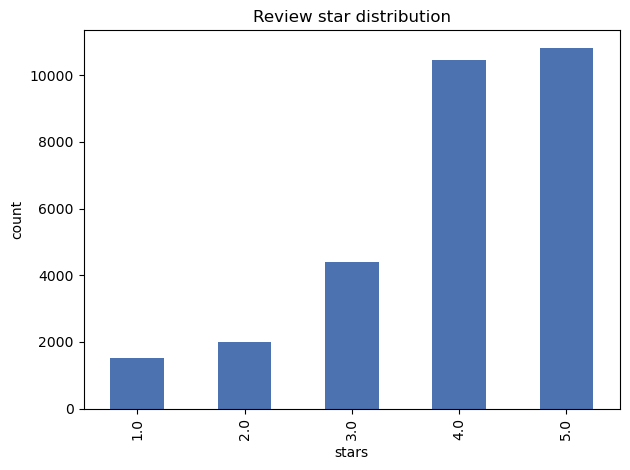

In [5]:
vc = rev["review_stars"].value_counts().sort_index()
print(vc, "\nmean:", round(rev["review_stars"].mean(), 3))
vc.plot(kind="bar", color="#4C72B0", title="Review star distribution")
plt.xlabel("stars"); plt.ylabel("count"); plt.tight_layout(); plt.show()

### 1b. Reviews per restaurant

min 406 max 2281 median 481
name
Pai Northern Thai Kitchen         2281
Khao San Road                     1466
Momofuku Noodle Bar                934
Bang Bang Ice Cream and Bakery     905
Gusto 101                          865
dtype: int64


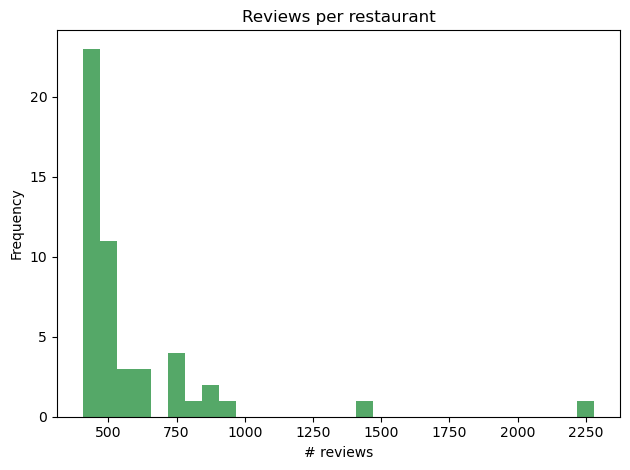

In [6]:
per = rev.groupby("name").size().sort_values(ascending=False)
print("min %d max %d median %d" % (per.min(), per.max(), per.median()))
print(per.head(5))
per.plot(kind="hist", bins=30, color="#55A868", title="Reviews per restaurant")
plt.xlabel("# reviews"); plt.tight_layout(); plt.show()

### 1c. Review length
Median ≈ 94 words with a long tail → reviews must be split into sentences before encoding.

count    29168.000000
mean       126.887651
std        112.349877
min          1.000000
25%         49.000000
50%         94.000000
75%        168.000000
max        955.000000
Name: word_len, dtype: float64


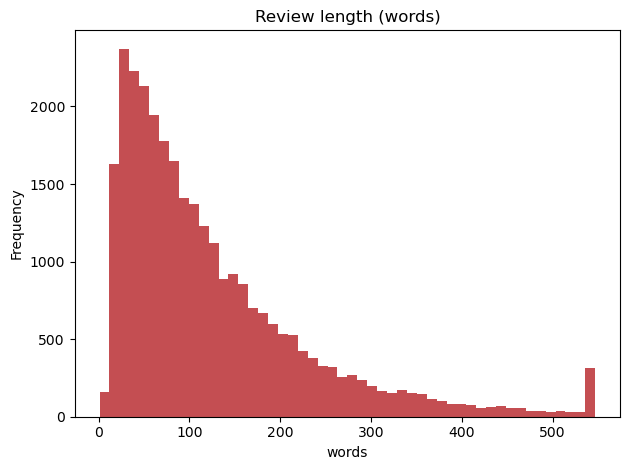

In [7]:
txt = rev["review_text"].fillna("").astype(str)
rev["word_len"] = txt.str.split().map(len)
print(rev["word_len"].describe())
rev["word_len"].clip(upper=rev["word_len"].quantile(0.99)).plot(
    kind="hist", bins=50, color="#C44E52", title="Review length (words)")
plt.xlabel("words"); plt.tight_layout(); plt.show()

### 1d. Categories & dates

In [8]:
cats = (rev.drop_duplicates("business_id")["categories"]
        .dropna().str.split(",").explode().str.strip())
print("distinct tags:", cats.nunique())
print(cats.value_counts().head(10))
dates = pd.to_datetime(rev["date"], errors="coerce")
print("\ndate range:", dates.min(), "->", dates.max())

distinct tags: 51
categories
Breakfast & Brunch    8
Japanese              7
Ramen                 5
Canadian (New)        4
Chinese               4
Noodles               4
Asian Fusion          3
Sandwiches            3
Sushi Bars            3
Desserts              2
Name: count, dtype: int64

date range: 2008-08-06 00:00:00 -> 2019-02-25 00:00:00


## 2. Language check — reviews
This is the decisive cell for the Thai-vs-English question.

In [9]:
sample = txt.sample(min(5000, len(txt)), random_state=0)
print((sample.map(script_of).value_counts(normalize=True) * 100).round(2))
print("\nexamples:")
for s in txt[txt.str.len() > 40].head(3):
    print(" -", s[:140].replace("\n", " "))

review_text
latin    100.0
Name: proportion, dtype: float64

examples:
 - Bit of a wait at the door. No problem. Spicy kimchi ramen was good. Very good? Almost. Ginger ale float was dumb and basic. Broth leftover a
 - Not sure why, but the shoyu broth and noodle here is way better than the Santouka in Vancouver. The pork jowl is absolutely delicious, but t
 - It should come to no surprise that I am a huge ramen fan. I had some truly amazing ramen in Japan and have felt ramen-withdrawal since then.


## 3. PMD — query × restaurant relevance

In [10]:
pmd = pd.read_csv(DATA / "PMD.csv")
pmd.columns = [c.strip() for c in pmd.columns]
pmd = pmd.drop_duplicates()  # one exact dup row in the raw file
ann = [c for c in pmd.columns if c.lower().startswith("annotator")]
agg = [c for c in pmd.columns if "Low" in c or "High" in c][0]
print("shape:", pmd.shape, "| queries:", pmd["query"].nunique(),
      "| restaurants:", pmd["Restaurant name"].nunique())
pmd.head(3)

shape: (5000, 8) | queries: 100 | restaurants: 50


,Restaurant name,query,Annotator1,Annotator2,Annotator3,Annotator4,Annotator5,If only Low or High
0,Ding Tai Fung,Can I have a cheat meal?,0,0,0,0,1,0
1,Ding Tai Fung,I feel chubby and need to lose weight,0,0,0,0,1,0
2,Ding Tai Fung,I want to have a crazy night with my friends,0,0,0,0,0,0


### 3a. Label balance — sparse positives (~27%)

In [11]:
print(pmd[agg].value_counts().sort_index())
print("positive rate: %.2f%%" % (pmd[agg].mean() * 100))

If only Low or  High
0    3652
1    1348
Name: count, dtype: int64
positive rate: 26.96%


### 3b. Annotator behaviour & agreement

Annotator1: 25.38%
Annotator2: 25.76%
Annotator3: 29.24%
Annotator4: 29.44%
Annotator5: 36.38%


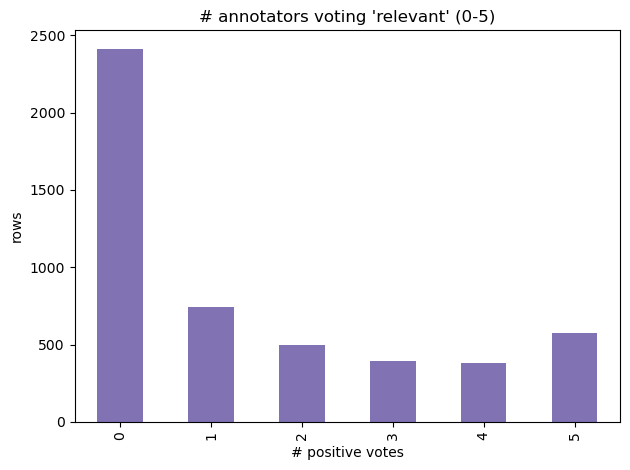

In [12]:
for c in ann:
    print("%s: %.2f%%" % (c, pmd[c].mean() * 100))
votesum = pmd[ann].sum(axis=1)
votesum.value_counts().sort_index().plot(
    kind="bar", color="#8172B3", title="# annotators voting 'relevant' (0-5)")
plt.xlabel("# positive votes"); plt.ylabel("rows"); plt.tight_layout(); plt.show()

### 3c. Language check — queries

In [13]:
q = pmd["query"].dropna().drop_duplicates()
print(q.map(script_of).value_counts())
print("\nexamples:")
for x in q.head(8):
    print(" -", x)

query
latin    100
Name: count, dtype: int64

examples:
 - Can I have a cheat meal?
 - I feel chubby and need to lose weight
 - I want to have a crazy night with my friends
 - I am on a budget
 - Want a place to get over this depression with friends
 - Late for work and I need to fill up before leaving
 - I want a place to hang out with my work friends
 - I want to show my friends the best restaurants in Toronto


## 4. Conclusion — Thai or English?

| Text | Thai | English |
|------|------|---------|
| reviews | 0% | **100%** |
| queries | 0% | **100%** |

RIRD is entirely **English** (Toronto / Yelp). Decisions:

1. **Use RIRD in English** as the *evaluation protocol + baseline* — it is the only
   source here with ground-truth relevance labels to score the fusion method.
2. **Do not** run Thai queries against RIRD — there is nothing Thai to match.
3. **Thai input** belongs to the **Wongnai / Foods-in-Thailand** corpora; transfer
   the validated fusion method there with a multilingual encoder.
